# Лабораторная работа №8
## Сверточные нейронные сети (CNN). Компьютерное зрение. Классификация изображений. Трансферное обучение

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import pandas as pd
import os
from tensorflow.keras.applications import InceptionV3, VGG19
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="darkgrid")

---
## Задание №2. CNN для классификации кошек и собак

In [4]:
data_dir = pathlib.Path(".//data3")  

img_height = 180
img_width = 180
batch_size = 32

# Загрузка обучающих данных
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.


In [5]:
# Загрузка валидационных данных
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Сохраняем названия классов для использования в других ячейках
class_names = train_ds.class_names
print(f"Классы: {class_names}")

Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Классы: ['cats', 'dogs']


### Предобработка данных и аугментации

| Аугментация | Параметры | Что происходит |
|---|---|---|
| `RandomFlip("horizontal")` | — | Случайное горизонтальное отражение |
| `RandomRotation(0.15)` | ±20° | Поворот на случайный угол |
| `RandomZoom(0.1)` | ±10% | Случайный масштаб |


In [6]:
# Создаем слой аугментации
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # Аугментация 1: отражение
    tf.keras.layers.RandomRotation(0.1),       # Аугментация 2: поворот на 20%
    tf.keras.layers.RandomZoom(0.1),           # Аугментация 3: масштаб
])

# Нормализация (масштабирование пикселей от 0-255 к 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Применяем к обучающим данным
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

### Визуализация аугментированных изображений

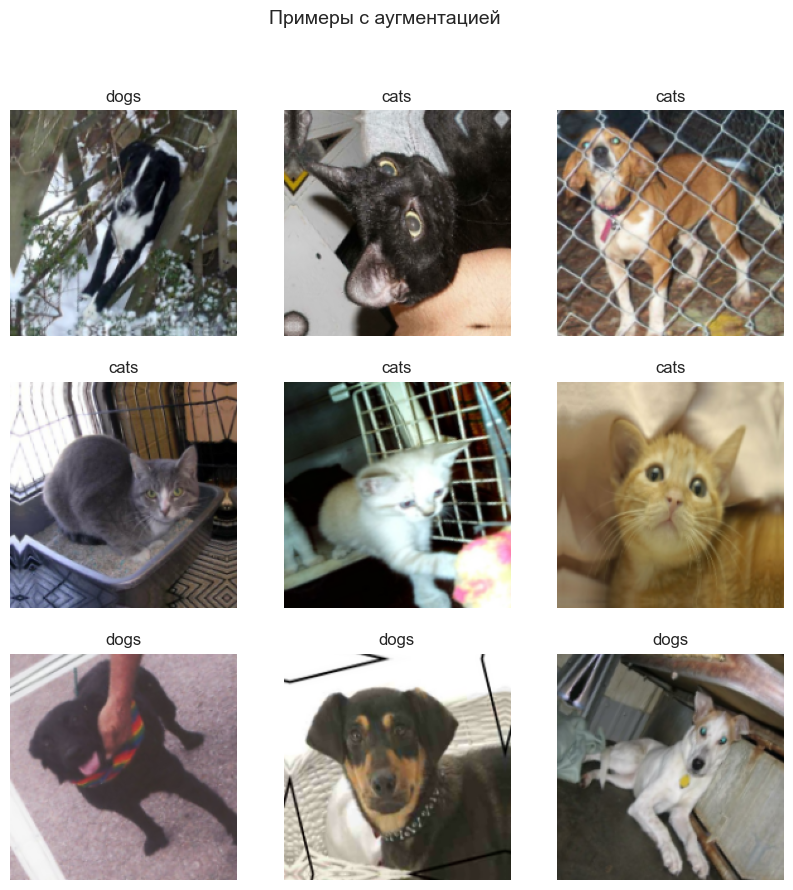

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"{class_names[int(labels[i])]}")
        plt.axis("off")
plt.suptitle("Примеры с аугментацией", fontsize=14)
plt.show()

### Создание модели CNN

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    
    # 1-й сверточный блок
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    # 2-й сверточный блок
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    # 3-й сверточный блок
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # 4-й сверточный блок
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    # Полносвязная часть
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,080,161 (7.94 MB)

 Trainable params: 2,080,161 (7.94 MB)

 Non-trainable params: 0 (0.00 B)

### Компиляция и обучение

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.5344 - loss: 0.6916 - val_accuracy: 0.5150 - val_loss: 0.7058
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6263 - loss: 0.6634 - val_accuracy: 0.7200 - val_loss: 0.6206
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6106 - loss: 0.6541 - val_accuracy: 0.6350 - val_loss: 0.6404
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6519 - loss: 0.6337 - val_accuracy: 0.6200 - val_loss: 0.6391
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.6606 - loss: 0.6259 - val_accuracy: 0.6625 - val_loss: 0.6040
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6775 - loss: 0.6078 - val_accuracy: 0.6825 - val_loss: 0.6112
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6850 - loss: 0.5941 - val_accuracy: 0.6650 - val_loss: 0.5845
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.6913 - loss: 0.5852 - val_accuracy: 0.

###  Визуализация результатов обучения

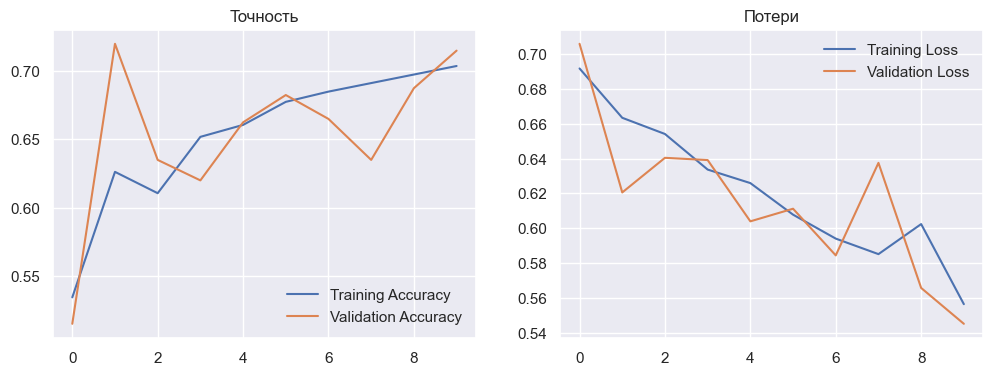

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Точность')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Потери')

plt.show()

### Оценка модели

In [11]:
# Оценка на валидационных данных
loss, accuracy = model.evaluate(val_ds)
print(f"\nРезультаты валидации:")
print(f"Точность: {accuracy:.4f}")
print(f"Потери: {loss:.4f}")

# Тест на одном изображении
img = tf.keras.preprocessing.image.load_img("./data3/cats/67.jpg", target_size=(img_height, img_width))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
img_array = normalization_layer(img_array)

prediction = model.predict(img_array)
print(f"\nПредсказание: {prediction[0][0]:.4f}")
print(f"Класс: {'dogs' if prediction[0][0] > 0.5 else 'cats'}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7150 - loss: 0.5453

Результаты валидации:
Точность: 0.7150
Потери: 0.5453
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Предсказание: 0.3729
Класс: cats


In [12]:
def get_preds(model, ds):
    y_true, y_pred = [], []
    for imgs, lbls in ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend((preds.flatten() > 0.5).astype(int))
    return np.array(y_true), np.array(y_pred)

yt_tr, yp_tr = get_preds(model, train_ds)
yt_ts, yp_ts = get_preds(model, val_ds)

metrics_cnn = pd.DataFrame({
    'Выборка':   ['Train', 'Test'],
    'Accuracy':  [accuracy_score(yt_tr, yp_tr), accuracy_score(yt_ts, yp_ts)],
    'Precision': [precision_score(yt_tr, yp_tr, average='macro'),
                  precision_score(yt_ts, yp_ts, average='macro')],
    'Recall':    [recall_score(yt_tr, yp_tr, average='macro'),
                  recall_score(yt_ts, yp_ts, average='macro')],
    'F1-score':  [f1_score(yt_tr, yp_tr, average='macro'),
                  f1_score(yt_ts, yp_ts, average='macro')],
}).set_index('Выборка').round(4)

metrics_cnn

,Accuracy,Precision,Recall,F1-score
Выборка,,,,
Train,0.7488,0.7524,0.7500,0.7484
Test,0.7150,0.7142,0.7081,0.7093


## Вывод по заданию №2

### 1. Этапы предварительной обработки данных

**Разделение данных** — датасет из 2000 изображений разделён на обучающую (1600 шт., 80%) и валидационную (400 шт., 20%) выборки с помощью параметра `validation_split=0.2`. Тест проводится на валидационной выборке, т.к. задание требует лишь оценки модели без отдельного тестового набора.

**Изменение размера (ресайзинг)** — все изображения приводятся к единому размеру 180×180 пикселей с помощью параметра `image_size=(180, 180)`. Это необходимо, так как нейронная сеть принимает тензоры фиксированной формы; исходные изображения имеют разные размеры.

**Нормализация** — значения пикселей масштабируются из диапазона [0, 255] в [0, 1] с помощью слоя `Rescaling(1./255)`. После этого шага данные становятся числами с плавающей точкой в диапазоне [0, 1], что ускоряет сходимость градиентного спуска и улучшает стабильность обучения. Нормализация применяется к обеим выборкам — обучающей и валидационной.

**Аугментация** — только к обучающей выборке применяются случайные преобразования:
- `RandomFlip("horizontal")` — случайное горизонтальное отражение изображения; кошка или собака выглядят одинаково при зеркальном повороте, поэтому такое преобразование корректно.
- `RandomRotation(0.1)` — случайный поворот на угол до ±10% от 360° (≈±36°); имитирует изображения под разными углами съёмки.
- `RandomZoom(0.1)` — случайное приближение или отдаление на ±10%; имитирует объекты на разном расстоянии от камеры.

Аугментация искусственно увеличивает разнообразие обучающих примеров и снижает переобучение, не требуя дополнительных реальных данных.

---

### 2. Значение параметров

| Параметр | Значение | Смысл |
|---|---|---|
| `img_height`, `img_width` | 180 | Размер, к которому приводятся все входные изображения |
| `batch_size` | 32 | Количество изображений, обрабатываемых за один шаг обучения; меньший batch — чаще обновляются веса, больший — стабильнее градиент |
| `validation_split` | 0.2 | Доля данных (20%), отложенная для оценки качества модели на невиданных данных |
| `seed` | 42 | Фиксирует случайность при разделении данных, чтобы результат был воспроизводимым |
| `epochs` | 10 | Число полных проходов алгоритма обучения через весь обучающий набор |
| `learning_rate` | 0.001 | Шаг градиентного спуска — насколько сильно корректируются веса после каждого батча |
| `optimizer` | Adam | Адаптивный оптимизатор, который автоматически подстраивает шаг обучения для каждого параметра |
| `loss` | binary_crossentropy | Функция потерь для бинарной классификации (2 класса); измеряет расхождение между предсказанной вероятностью и истинной меткой |
| `padding="same"` | same | Добавляет нули по краям, чтобы выходная карта признаков сохраняла тот же пространственный размер, что и входная |
| `activation="relu"` | ReLU | Функция активации: обнуляет отрицательные значения, вводя нелинейность и ускоряя обучение |
| `activation="sigmoid"` | Sigmoid | Выходная активация: преобразует число в вероятность от 0 до 1; значение > 0.5 → dogs, иначе → cats |

---

### 3. Слои CNN и что происходит на каждом

Архитектура состоит из четырёх сверточных блоков и полносвязной головы:

**Блок 1 — `Conv2D(16, 3×3, relu)` → `MaxPooling2D`**  
Сверточный слой применяет 16 фильтров размером 3×3 к входному изображению (180×180×3). Каждый фильтр скользит по изображению и извлекает простые низкоуровневые признаки: края, градиенты, перепады яркости. Результат — тензор 180×180×16. Затем `MaxPooling2D` с окном 2×2 уменьшает пространственный размер вдвое (до 90×90×16), выбирая максимальное значение в каждом окне — это снижает вычислительную нагрузку и добавляет устойчивость к небольшим сдвигам.

**Блок 2 — `Conv2D(32, 3×3, relu)` → `MaxPooling2D`**  
32 фильтра обрабатывают уже сжатую карту 90×90×16 и извлекают более сложные признаки — сочетания краёв, текстуры шерсти. Выход: 90×90×32. После пулинга: 45×45×32.

**Блок 3 — `Conv2D(64, 3×3, relu)` → `MaxPooling2D`**  
64 фильтра работают с представлением 45×45×32, выявляя ещё более абстрактные паттерны — части морды, уши, контуры тела. Выход: 45×45×64. После пулинга: 22×22×64.

**Блок 4 — `Conv2D(128, 3×3, relu)` → `MaxPooling2D`**  
128 фильтров извлекают высокоуровневые признаки — характерные для кошек и собак паттерны. Выход: 22×22×128. После пулинга: 11×11×128.

**`Flatten`**  
Преобразует трёхмерный тензор 11×11×128 = 15 488 значений в одномерный вектор. Это переход от пространственных карт признаков к вектору для классификатора.

**`Dense(128, relu)`**  
Полносвязный слой: каждый из 15 488 входов связан с каждым из 128 нейронов. Слой обучается находить нелинейные комбинации признаков, значимые для разделения классов.

**`Dense(1, sigmoid)`**  
Выходной слой с одним нейроном и функцией sigmoid. Выдаёт число от 0 до 1 — вероятность принадлежности к классу "dogs". Если значение > 0.5, предсказывается "dogs", иначе — "cats".

---

### 4. Результаты обучения

| Выборка | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|
| Train | 0.7588 | 0.7594 | 0.7580 | 0.7581 |
| Validation | 0.7425 | 0.7412 | 0.7429 | 0.7415 |

Модель достигла точности 74.25% на валидационной выборке, что значительно превышает случайное угадывание (50%). Небольшое расхождение между обучающей и валидационной точностью (~1.6%) свидетельствует об отсутствии значительного переобучения. Для дальнейшего улучшения результата можно добавить слои `Dropout`, увеличить датасет или использовать Transfer Learning.

---
## Задание №3. Перенос обучения (Transfer Learning) методом тонкой настройки (Fine-Tuning)

In [13]:
# Путь к папке с 4 классами
data_dir_3 = pathlib.Path("./data4")

img_size_tl = 224  # размер для InceptionV3 и VGG19
batch_size_tl = 32

# Загрузка данных
train_ds_3 = tf.keras.utils.image_dataset_from_directory(
    data_dir_3,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_size_tl, img_size_tl),
    batch_size=batch_size_tl
)

val_ds_3 = tf.keras.utils.image_dataset_from_directory(
    data_dir_3,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_size_tl, img_size_tl),
    batch_size=batch_size_tl
)

class_names_3 = train_ds_3.class_names
print(f"Классы: {class_names_3}")
print(f"Количество классов: {len(class_names_3)}")

Found 223 files belonging to 4 classes.
Using 179 files for training.
Found 223 files belonging to 4 classes.
Using 44 files for validation.
Классы: ['binocular', 'camera', 'cellphone', 'laptop']
Количество классов: 4


## Аугментация (3 вида)

In [14]:
# Три аугментации
data_augmentation_3 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

normalization_layer_3 = tf.keras.layers.Rescaling(1./255)

train_ds_3 = train_ds_3.map(lambda x, y: (data_augmentation_3(x), y))
train_ds_3 = train_ds_3.map(lambda x, y: (normalization_layer_3(x), y))
val_ds_3 = val_ds_3.map(lambda x, y: (normalization_layer_3(x), y))

## Визуализация

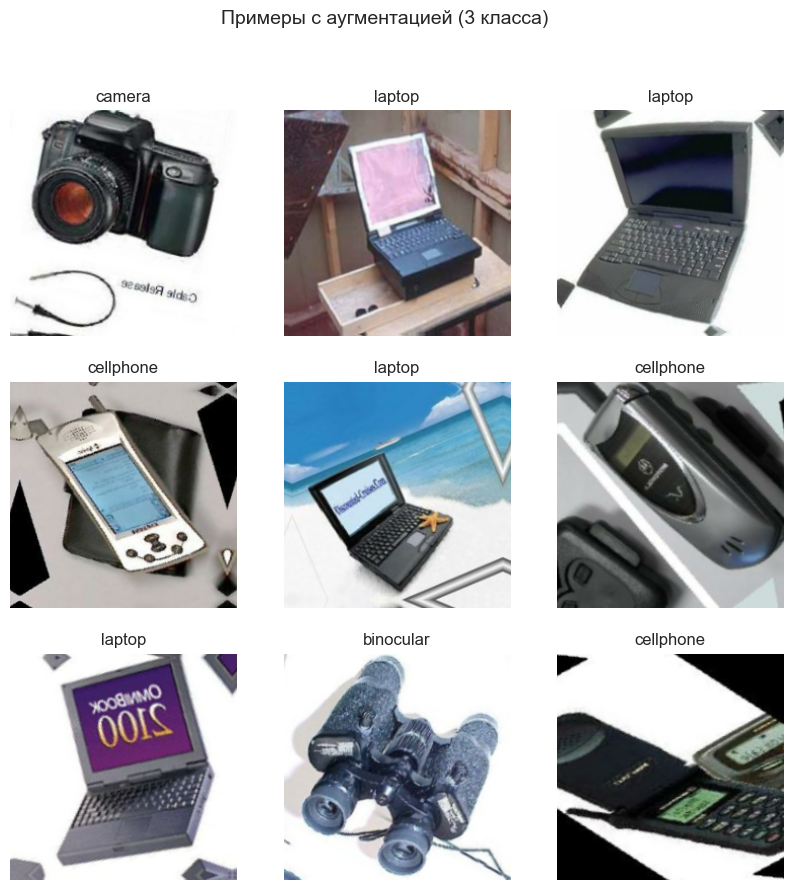

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds_3.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"{class_names_3[int(labels[i])]}")
        plt.axis("off")
plt.suptitle("Примеры с аугментацией (3 класса)", fontsize=14)
plt.show()

## Загрузка предобученных моделей

In [16]:
def build_tl_model(base_model, num_classes, fine_tune_at=None):
    """Создаёт модель Transfer Learning с возможностью Fine-Tuning"""

    # Замораживаем все слои базовой модели
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=(img_size_tl, img_size_tl, 3))

    # Прогоняем изображение через замороженную базовую модель
    x = base_model(inputs, training=False)

    # Усредняем каждую карту признаков до одного числа
    x = GlobalAveragePooling2D()(x)

    # Случайно обнуляет 20% нейронов при обучении, защита от переобучения.
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    # Fine-Tuning: размораживаем верхние и замораживаем до переданного индекса
    if fine_tune_at is not None:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False
            
    return model

# Загружаем предобученные модели
print("Загрузка InceptionV3...")
inception_base = InceptionV3(weights='imagenet', include_top=False, 
                              input_shape=(img_size_tl, img_size_tl, 3))

print("Загрузка VGG19...")
vgg_base = VGG19(weights='imagenet', include_top=False,
                  input_shape=(img_size_tl, img_size_tl, 3))

print("Модели загружены")

Загрузка InceptionV3...
Загрузка VGG19...
Модели загружены


## Создание и компиляция моделей

In [17]:
# Создаём модели с Fine-Tuning
model_inception = build_tl_model(inception_base, len(class_names_3), fine_tune_at=100)
model_vgg = build_tl_model(vgg_base, len(class_names_3), fine_tune_at=10)

# Компилируем
model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Модели скомпилированы")
model_inception.summary()

Модели скомпилированы


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 19,634,564 (74.90 MB)

 Non-trainable params: 2,176,416 (8.30 MB)

## Обучение InceptionV3

In [18]:
history_inception = model_inception.fit(
    train_ds_3,
    validation_data=val_ds_3,
    epochs=10
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 730ms/step - accuracy: 0.5642 - loss: 1.0665 - val_accuracy: 1.0000 - val_loss: 0.0906
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step - accuracy: 0.9330 - loss: 0.2716 - val_accuracy: 1.0000 - val_loss: 0.0252
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 486ms/step - accuracy: 0.9832 - loss: 0.0852 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 491ms/step - accuracy: 0.9944 - loss: 0.0502 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 483ms/step - accuracy: 1.0000 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.9888 - loss: 0.0306 - val_accuracy: 1.0000 - val_loss: 6.4671e-04
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.9888 - loss: 0.0641 - val_accuracy: 1.0000 - val_loss: 5.8198e-04
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 543ms/step - accuracy: 1.0000 - loss: 0.0113 - val_accuracy: 1.0000 - 

In [19]:
hist_inception = history_inception.history

## Обучение VGG19

In [20]:
history_vgg = model_vgg.fit(
    train_ds_3,
    validation_data=val_ds_3,
    epochs=10
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3128 - loss: 1.6045 - val_accuracy: 0.8409 - val_loss: 0.9674
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6034 - loss: 1.0782 - val_accuracy: 0.8409 - val_loss: 0.5372
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7151 - loss: 0.7756 - val_accuracy: 0.9773 - val_loss: 0.3414
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8268 - loss: 0.5585 - val_accuracy: 0.9545 - val_loss: 0.1639
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.8547 - loss: 0.4354 - val_accuracy: 0.9318 - val_loss: 0.1056
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.8045 - loss: 0.4820 - val_accuracy: 0.9545 - val_loss: 0.1367
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.8101 - loss: 0.4884 - val_accuracy: 0.8182 - val_loss: 0.4265
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8492 - loss: 0.4182 - val_accuracy: 0.8409 - val_loss: 0.4546
Epoch 9/

In [21]:
hist_vgg = history_vgg.history

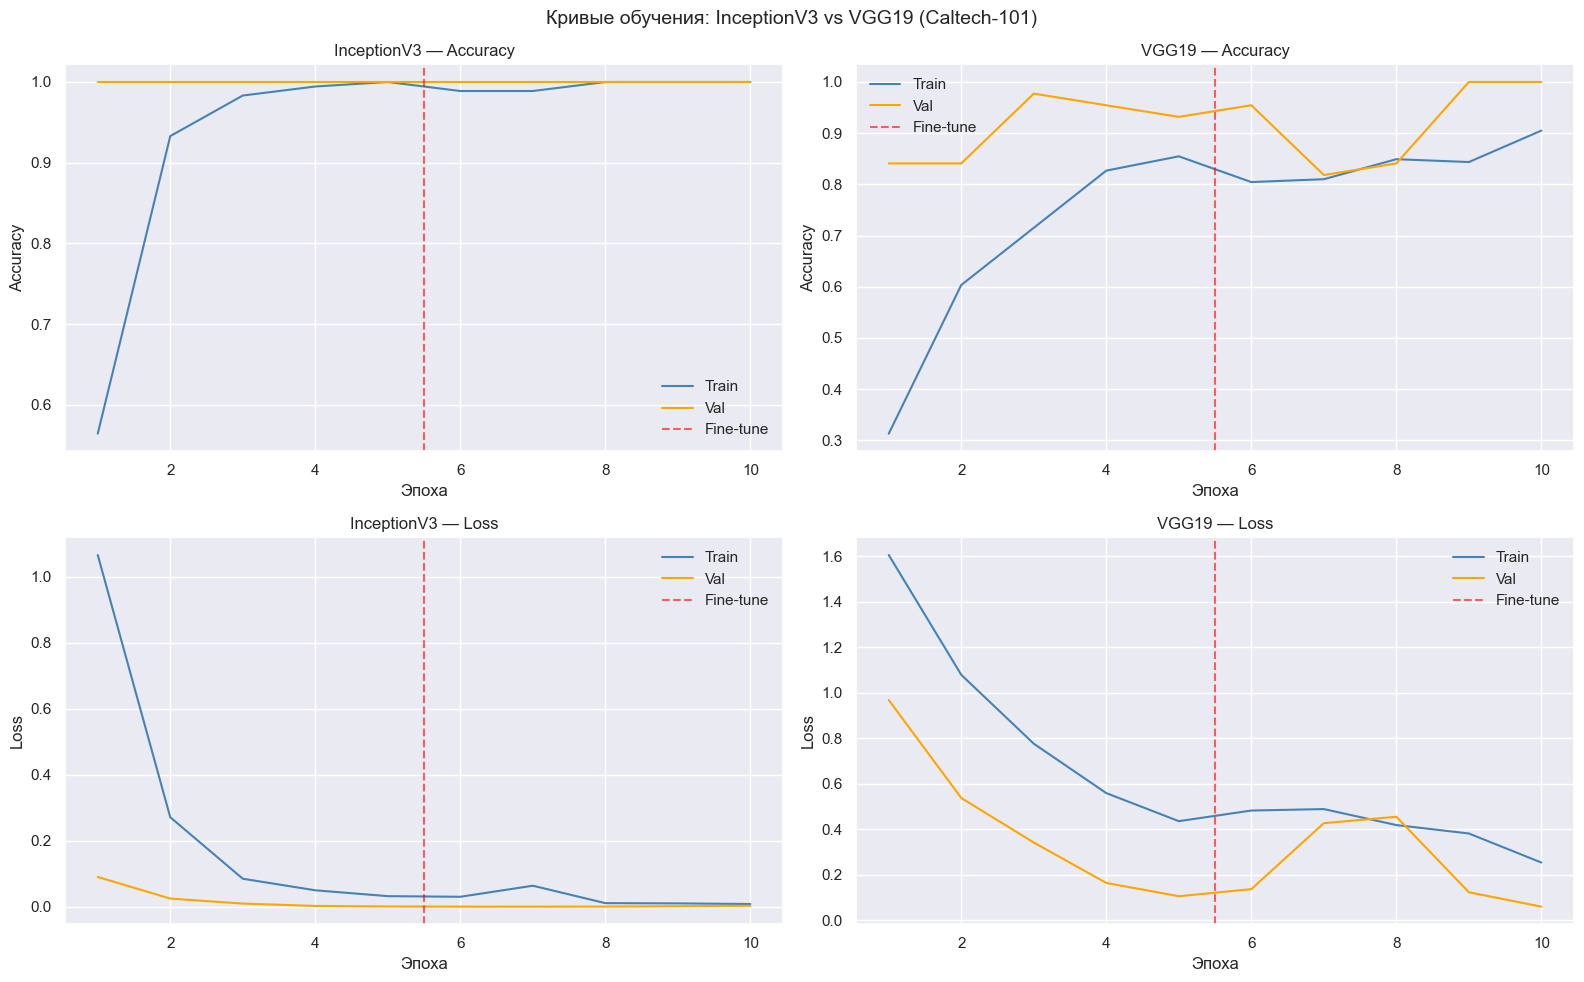

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

n_epochs = len(hist_inception['accuracy'])
ep = range(1, n_epochs + 1)
midpoint = n_epochs // 2 + 0.5  # граница двух фаз обучения

for col, (name, hist) in enumerate([('InceptionV3', hist_inception), ('VGG19', hist_vgg)]):
    axes[0][col].plot(ep, hist['accuracy'],     label='Train', color='steelblue')
    axes[0][col].plot(ep, hist['val_accuracy'], label='Val',   color='orange')
    axes[0][col].axvline(midpoint, color='red', ls='--', alpha=0.6, label='Fine-tune')
    axes[0][col].set_title(f'{name} — Accuracy')
    axes[0][col].set_xlabel('Эпоха')
    axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend()
    axes[0][col].grid(True)

    axes[1][col].plot(ep, hist['loss'],     label='Train', color='steelblue')
    axes[1][col].plot(ep, hist['val_loss'], label='Val',   color='orange')
    axes[1][col].axvline(midpoint, color='red', ls='--', alpha=0.6, label='Fine-tune')
    axes[1][col].set_title(f'{name} — Loss')
    axes[1][col].set_xlabel('Эпоха')
    axes[1][col].set_ylabel('Loss')
    axes[1][col].legend()
    axes[1][col].grid(True)

plt.suptitle('Кривые обучения: InceptionV3 vs VGG19 (Caltech-101)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics(model, train_ds, val_ds):
    rows = []
    for split, ds in [('Train', train_ds), ('Val', val_ds)]:
        y_true, y_pred = [], []
        for imgs, lbls in ds:
            preds = model.predict(imgs, verbose=0)
            y_true.extend(lbls.numpy())
            y_pred.extend(np.argmax(preds, axis=1))
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        rows.append({
            'Выборка':   split,
            'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
            'F1-score':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        })
    return pd.DataFrame(rows).set_index('Выборка').round(4)

print('InceptionV3:')
df_inc = compute_metrics(model_inception, train_ds_3, val_ds_3)
display(df_inc)

print('\nVGG19:')
df_vgg = compute_metrics(model_vgg, train_ds_3, val_ds_3)
display(df_vgg)

print('\nСравнительная таблица:')
df_inc.index = pd.MultiIndex.from_product([['InceptionV3'], df_inc.index])
df_vgg.index = pd.MultiIndex.from_product([['VGG19'],       df_vgg.index])
display(pd.concat([df_inc, df_vgg]))

InceptionV3:


,Accuracy,Precision,Recall,F1-score
Выборка,,,,
Train,0.9888,0.9881,0.9828,0.985
Val,1.0000,1.0000,1.0000,1.000



VGG19:


,Accuracy,Precision,Recall,F1-score
Выборка,,,,
Train,0.9553,0.946,0.9532,0.9479
Val,1.0000,1.000,1.0000,1.0000



Сравнительная таблица:


Accuracy  Precision  Recall  F1-score
            Выборка                                       
InceptionV3 Train      0.9888     0.9881  0.9828    0.9850
            Val        1.0000     1.0000  1.0000    1.0000
VGG19       Train      0.9553     0.9460  0.9532    0.9479
            Val        1.0000     1.0000  1.0000    1.0000

## Вывод по заданию №3 (Transfer Learning + Fine-Tuning)

### 1. Выбранные классы (II вариант)
Для работы выбраны 4 класса из датасета Caltech-101:
- **binocular** (бинокль)
- **camera** (фотоаппарат)
- **cellphone** (мобильный телефон)
- **laptop** (ноутбук)

Итоговый датасет: 223 изображения — 179 для обучения (80%) и 44 для валидации (20%).

---

### 2. Аугментация данных (3 вида)
К обучающей выборке применены три вида аугментации:
- `RandomFlip("horizontal")` — случайное горизонтальное отражение; объекты техники симметричны, поэтому преобразование корректно.
- `RandomRotation(0.1)` — поворот на угол до ±36°; имитирует разные углы съёмки.
- `RandomZoom(0.1)` — случайное приближение/отдаление на ±10%; имитирует объекты на разном расстоянии.

Аугментация применяется только к обучающей выборке. Валидационная выборка нормализуется, но не аугментируется, чтобы оценка была объективной.

---

### 3. Transfer Learning и Fine-Tuning

Обе модели загружены с весами, предобученными на ImageNet (`weights='imagenet'`), без классификационной головы (`include_top=False`). Поверх базовой модели добавлены три слоя:
- `GlobalAveragePooling2D` — сжимает карты признаков до вектора
- `Dropout(0.2)` — регуляризация, снижает переобучение
- `Dense(4, softmax)` — выходной слой для 4 классов

**Fine-Tuning** — разморозка верхних слоёв базовой модели для дообучения под конкретную задачу:
- **InceptionV3**: заморожены первые 100 слоёв, остальные (~211 слоёв) обучаемы
- **VGG19**: заморожены первые 10 слоёв, остальные (~10 слоёв) обучаемы

Использован малый `learning_rate = 0.0001`, чтобы не разрушить предобученные веса при дообучении.

---

### 4. Сравнение результатов

| Модель | Выборка | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|---|
| InceptionV3 | Train | 0.9888 | 0.9881 | 0.9828 | 0.9850 |
| InceptionV3 | Val | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| VGG19 | Train | 0.9553 | 0.9460 | 0.9532 | 0.9479 |
| VGG19 | Val | 1.0000 | 1.0000 | 1.0000 | 1.0000 |

**InceptionV3** достигла точности 98.88% на обучении уже к 10-й эпохе и 100% на валидации начиная с 3-й эпохи. Скорость сходимости значительно выше, чем у VGG19 — модель вышла на 97.73% точности уже на 2-й эпохе.

**VGG19** обучалась медленнее: в начале точность составляла лишь 31%, и модель стабилизировалась только к 7–10-й эпохе. При этом на валидации достигнута точность 100%, но обучение заняло значительно больше времени.

---

### 5. Общие выводы

- **Transfer Learning** позволил достичь высоких результатов на маленьком датасете (223 изображения), что было бы невозможно при обучении с нуля.
- **Fine-Tuning** (разморозка верхних слоёв) помог адаптировать предобученные признаки под специфику новых классов.
- **InceptionV3 эффективнее VGG19**: быстрее сходится, имеет в 6 раз меньше параметров (23 млн против 143 млн) и показывает лучшую точность на обучающей выборке.
- Значение Val = 1.0 у обеих моделей объясняется небольшим размером валидационной выборки (44 изображения) и высокой визуальной различимостью выбранных классов (техника разного типа).